In [332]:
%matplotlib inline

In [333]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro


# Bulgarian Electricity Prices: A Statistical Analysis (2016–2025)

## 1. Introduction

Electricity is the most time-sensitive commodity in a modern economy. Unlike grain or oil, it cannot be stored cheaply at scale; supply must equal demand at every instant, and the price that emerges from this constraint reflects the marginal cost of producing the last megawatt-hour needed to keep the grid balanced. When the weather changes, both sides of that balance shift — heating and cooling demand respond to temperature, wind generation responds to wind, hydro reservoirs respond to precipitation — and the wholesale price moves in response. The relationship between weather and wholesale electricity price is one of the most direct, observable links between the natural environment and a market.

This project examines that relationship in the Bulgarian context, using daily data from October 2016 through December 2025.
### 1.1 The Bulgarian energy market context

Bulgaria's electricity market is small by European standards, but it has all the structural features of a modern liberalised market: a wholesale exchange (IBEX), participation in the European day-ahead coupling mechanism, a generation mix that is geographically and technologically varied (nuclear, lignite, hydro, wind, solar), and exposure to international gas and carbon prices. It is also a market in transition. Over the analysis window, Bulgaria has lived through the launch of its day-ahead exchange, the COVID demand shock, the 2021–2022 European energy crisis, and the post-crisis adjustment.

Two features of the Bulgarian market shape this analysis specifically. The wholesale day-ahead price — the variable studied here — is set on IBEX, which began clearing trades on 1 October 2016. This launch date sets the lower bound of the analytical window: there is no Bulgarian day-ahead price data before October 2016 because no liquid day-ahead market existed before then. Separately, household electricity prices in Bulgaria are largely regulated by KEVR (the Energy and Water Regulatory Commission) rather than set by the market. This means the weather-to-price relationship visible in the data describes how the wholesale market responds to weather, not how household bills respond. Section 2.1 develops this distinction in detail.

### 1.2 Literature Review

The relationship between weather variables and electricity prices is well-established in energy economics research. Boogen et al. (2024) estimate the effect of temperature, wind speed, solar radiation, and precipitation on wholesale electricity prices across six European countries, finding that weather impacts prices in a nonlinear manner and identifying thresholds at which weather effects amplify significantly. Haluška et al. (2025) analyze meteorological variables including temperature, wind speed, and humidity on electricity prices across Central European countries using ENTSO-E data from 2019 to 2024, finding that results are country-specific and asymmetric. Trebbien et al. (2024) provide a comprehensive analysis of patterns and correlations in European day-ahead electricity prices between 2019 and 2023, noting the period was characteristically abnormal due to the energy crisis and that weather is a common driving factor across bidding zones.

No study to our knowledge focuses specifically on Bulgaria over a decade-long period that includes the 2021–2022 energy crisis. This analysis aims to fill that gap.

### 1.3 Research Questions
The analysis is built around three explicitly numbered questions:

1. **How strongly do weather variables correlate with real (inflation-adjusted) Bulgarian day-ahead electricity prices?**
2. **Which weather variable has the strongest independent relationship with price?**
3. **Did the 2021–2022 energy crisis fundamentally alter the weather–price relationship, and if so, how?**

The first question establishes the basic statistical relationship. The second sharpens it by separating out variables that are correlated *because* they correlate with each other (temperature and cloud cover, for example) from variables that contribute independently. The third treats the energy crisis as a natural experiment: a period when external shocks to gas prices and supply disrupted the normal relationship between domestic conditions and domestic prices, and asks whether the disruption persisted, reversed, or simply faded.

### 1.4 Scope and Limitations

This is a correlational study, not a causal one. Weather and price are observed together in the data; nothing here establishes that weather *causes* price changes, only that the two move together (or fail to) under the conditions present in the dataset. The mechanisms by which weather affects electricity prices — heating and cooling demand, renewable generation, fuel substitution — are well understood physically and economically, and the correlations measured here are consistent with those mechanisms. But the analysis itself cannot rule out confounding factors that move with weather (seasonal demand patterns, fuel price cycles, holiday effects), and it does not attempt to.

The wholesale–retail distinction noted above also bounds the analysis. The findings describe how the *Bulgarian wholesale market* prices weather risk, not how Bulgarian households experience weather-driven price changes at the meter. The retail tariff, by design, insulates households from short-term wholesale movements.

Finally, the analysis is observational. The data records what happened; it does not say what would have happened under different conditions. Statements about the energy crisis "altering the relationship" describe what is visible in the before-and-after data, not what would have been true in a counterfactual world without the crisis.

### 1.5 Assumptions

This analysis rests on a small number of explicit assumptions. Each is stated here so that any reader can evaluate whether it holds, and so that any limitation in the conclusions can be traced back to the assumption that produced it.

- **Wholesale market prices reflect supply-and-demand response to weather.** The day-ahead clearing price is treated as the variable on which weather conditions can plausibly act. Regulated retail tariffs and long-term bilateral contracts are not part of this analysis.
- **The five chosen cities are an adequate proxy for national weather.** Sofia, Plovdiv, Varna, Burgas, and Ruse are assumed to span Bulgaria's main population centres and climate zones well enough to construct a national index. Smaller cities and rural areas are not directly represented.
- **Population is an acceptable proxy for electricity demand.** Cities with more people are assumed to contribute more to national electricity demand. The true weighting — by actual electricity consumption — is not publicly available at the regional level.
- **Population weights are stable enough to fix at a single reference year.** Bulgarian city populations did shift over the analysis window, but the shifts are assumed to be small relative to the underlying proxy uncertainty. Static weights anchored to 2020 are used throughout.
- **HICP captures the inflation relevant to euro-denominated electricity prices.** The Bulgarian HICP is assumed to be the appropriate deflator. A producer price index or energy-specific deflator might give different real-price values; the choice of consumer-side HICP is consistent with how end users experience prices.
- **ERA5 reanalysis is treated as ground truth for historical weather.** ERA5 is a model output rather than a direct measurement, but it is assumed to represent past weather faithfully enough for the daily, country-aggregated resolution used here.
- **Daily resolution is fine enough to capture the weather–price relationship.** Intraday dynamics — the morning–evening peak structure, hourly weather extremes — are aggregated away. The research questions are about multi-year patterns, and daily resolution is assumed sufficient for those.
- **The October 2016 – December 2025 window contains enough variation to support the analysis.** The window deliberately includes the COVID shock and the 2021–2022 energy crisis. These are treated as natural experiments rather than excluded as outliers, on the assumption that what the analysis can learn from them is more valuable than the cleanliness lost by including them.
- **Statistical association is the claim being made — not causation.** Every result in this analysis is correlational. Weather and price are observed together; nothing here establishes that weather *causes* price changes, only that the two move together (or fail to) in the data.

## 2. Data Sources

This analysis draws on three independent data sources, combined to form a single daily time series spanning October 2016 through December 2025. The three sources answer different questions that the others cannot: *what did electricity cost on the wholesale market?*, *what was the weather?*, and *what was a euro actually worth?* Eurostat additionally provides population data for the five cities used to construct the national weather index, described alongside the HICP. No single source could answer all of these questions, and substituting any one of them with a derived or modeled equivalent would compromise the analysis.

### 2.1 Source 1 — Ember: Day-Ahead Electricity Prices

Ember is an independent climate and energy think tank that publishes a curated dataset of European wholesale day-ahead electricity prices, sourced originally from ENTSO-E's Transparency Platform. The dataset provides daily clearing prices in nominal euros per megawatt-hour (€/MWh) for Bulgaria.

The data series for Bulgaria begins on 1 October 2016 — the date IBEX, the Bulgarian Independent Energy Exchange, launched and began clearing day-ahead trades. There is no Bulgarian day-ahead price data before this date because no liquid wholesale day-ahead market existed in Bulgaria before then. This sets the lower bound of the analysis window.

The day-ahead market is the central price-discovery mechanism for *wholesale* electricity in Bulgaria. Each day, generators and large buyers submit bids for the following day's hourly delivery, and IBEX clears them into a single price per hour. Ember aggregates these hourly clearing prices into a daily mean, which is the variable used throughout this notebook. Daily resolution is appropriate here because the weather data will also be aggregated to daily resolution, and because the research questions concern multi-year patterns rather than intraday dynamics.

It is worth being explicit about what this price represents and what it does not. The day-ahead price is the wholesale market clearing price — what generators receive for selling electricity to large buyers (utilities, industrial consumers, traders) one day in advance. It reflects the marginal cost of the last unit of electricity needed to meet expected demand, typically a gas-fired plant during peak hours. It does not reflect what Bulgarian households pay on their electricity bills. Household prices in Bulgaria are largely regulated by KEVR (the Energy and Water Regulatory Commission), updated only a few times per year, and include network charges, taxes, and supplier margins on top of the underlying energy cost. Long-term bilateral contracts negotiated outside the exchange are also not reflected in this dataset.

This distinction matters for interpreting the results. The analysis will reveal how the *wholesale market* prices weather risk — how generators and buyers respond to changing supply and demand conditions driven by temperature, wind, precipitation, and so on. It will not reveal how weather affects what consumers pay at the meter, because the regulated retail tariff insulates Bulgarian households from short-term wholesale fluctuations. The wholesale market is the appropriate place to study weather-price relationships precisely because it is the part of the system that responds to weather; the retail tariff, by design, smooths these signals out.

- **Provider:** Ember
- **License:** CC-BY-4.0 (free reuse with attribution)
- **URL:** [ember-energy.org/data/european-wholesale-electricity-price-data](https://ember-energy.org/data/european-wholesale-electricity-price-data)
- **Original source:** ENTSO-E Transparency Platform (Bulgarian market: IBEX)
- **Variable used:** Daily mean day-ahead clearing price, nominal €/MWh
- **Coverage:** 2016-10-01 through 2025-12-31
### 2.2 Source 2 — Open-Meteo: Historical Weather

Open-Meteo provides a free historical weather API that serves reanalysis data from the ERA5 dataset, produced by the European Centre for Medium-Range Weather Forecasts (ECMWF) under the Copernicus Climate Change Service. Reanalysis data is not raw observation — it is the output of a physics-based atmospheric model that ingests observations from weather stations, satellites, and balloons, and produces a globally consistent gridded estimate of past weather. This is the standard approach for historical climate research and is preferable to relying on a single weather station, which may have gaps, instrument changes, or local microclimate effects unrepresentative of the broader region.

Five variables are pulled at hourly resolution and aggregated to daily values: temperature (mean), precipitation (sum), wind speed (mean), cloud cover (mean), and snowfall (sum). The aggregation method is chosen to match the physical meaning of each variable — precipitation and snowfall accumulate, while temperature, wind, and cloud cover are averaged.

Although the Open-Meteo source has weather data going back decades, it is filtered to October 2016 onward to align with the price series. Weather observations from periods when no price data exists cannot enter the analysis, since the analysis is built around the weather–price relationship.

#### Why five cities, not one

Bulgarian electricity demand is not uniform across the country. A national-scale weather variable is needed to correlate with a national-scale price. Using only Sofia would bias the analysis toward conditions in the capital and miss the contributions of coastal cities (where summer cooling demand peaks) and the Danube plain (which has its own climate regime). Weather is therefore pulled for five Bulgarian cities — Sofia, Plovdiv, Varna, Burgas, and Ruse — chosen to span the country's main population centres and climate zones. The cities are then combined into a single national weather index. The construction of that index, including the weighting scheme and its limitations, is documented in Section 3.

- **Provider:** Open-Meteo (Historical Weather API)
- **License:** CC-BY-4.0
- **URL:** [open-meteo.com/en/docs/historical-weather-api](https://open-meteo.com/en/docs/historical-weather-api)
- **Underlying dataset:** ERA5 reanalysis (ECMWF / Copernicus Climate Change Service)
- **Variables used:** Temperature, precipitation, wind speed, cloud cover, snowfall
- **Resolution:** Hourly, aggregated to daily
- **Cities:** Sofia, Plovdiv, Varna, Burgas, Ruse
- **Coverage:** 2016-10-01 through 2025-12-31
### 2.3 Source 3 — Eurostat: Inflation and Population

Eurostat is the statistical office of the European Union. It publishes harmonised statistics across member states, drawing on data collected by each country's National Statistical Institute — for Bulgaria, the National Statistical Institute (NSI Bulgaria). Two pieces of data from Eurostat are used in this analysis. They serve different purposes but share a single publisher, a single license, and a single citation chain, and so are described together here. The HICP is loaded as a CSV; the population values are small enough to be entered inline in the notebook (five numbers, held fixed across the analysis window), with the Eurostat source cited at the point of use.
#### 2.3.1 HICP — Harmonised Index of Consumer Prices

The HICP is the official inflation measure published by Eurostat for all EU member states. National HICP data are collected by NSI Bulgaria and harmonised by Eurostat under a common methodology that makes the indices comparable across countries. The harmonised methodology is the appropriate index basis here, because Bulgarian wholesale electricity is sold on euro-denominated markets, and the HICP reflects the same currency basis as the price data.

The role of this dataset in the analysis is structural, not exploratory. Nominal prices in 2025 cannot be compared directly to nominal prices in 2016, because a euro in 2025 buys substantially less than a euro in 2016. Failing to deflate the price series would mean that any apparent long-term price trend would conflate two distinct phenomena: real changes in the cost of electricity (the thing we want to study) and the general erosion of the euro's purchasing power (which has nothing to do with weather). Section 3 documents the deflation procedure and shows the difference it makes to the price series.

The HICP is published monthly. Daily prices are deflated using the HICP value for the month in which each price observation falls — this is the standard approach and is appropriate given that the index does not change at daily resolution.

- **Variable used:** Monthly HICP index for Bulgaria, base year 2015 = 100
- **URL:** [ec.europa.eu/eurostat/databrowser/view/PRC_HICP_MIDX](https://ec.europa.eu/eurostat/databrowser/view/PRC_HICP_MIDX)
- **Coverage:** 2016-10 through 2025-12
#### 2.3.2 City Population

Population data for the five cities used in the weather index — Sofia, Plovdiv, Varna, Burgas, and Ruse — comes from Eurostat's Urban Audit (dataset `urb_cpop1`). It is used in a supporting role only: to assign weights when combining the five city-level weather series into a single national weather index. Population is used as a proxy for electricity demand, on the reasoning that cities with more people contribute more to national demand. This is a defensible-not-correct choice, and its limitations are discussed in Section 3.

A single reference year (2020) is used to compute the weights, which are then held fixed across the entire analysis period. Bulgarian city populations did shift modestly across the window — Sofia gained residents while smaller cities lost them — but these shifts are small relative to the proxy nature of population-as-demand-weight. Allowing the weights to vary year by year would couple the weather index to demographic drift in a way that complicates the interpretation of the index across time. Holding the weights fixed prioritises a stable, interpretable index over marginal demographic precision. This decision is documented explicitly in Section 3.

The five population values were pulled once from the Eurostat API and saved as a small CSV in the project's `data/` directory, alongside the other source files. Subsequent notebook runs read from this CSV directly. The reproducibility chain is intact — anyone can regenerate the CSV by re-running the original Eurostat fetch (preserved in the notebook's git history), and the values themselves are referenced by both Eurostat dataset code and city code in the source comment.

- **Variable used:** Population for Sofia, Plovdiv, Varna, Burgas, Ruse, reference year 2020
- **Source dataset:** [ec.europa.eu/eurostat/databrowser/view/URB_CPOP1](https://ec.europa.eu/eurostat/databrowser/view/URB_CPOP1)
- **Local cache:** `data/city_population_2020.csv`

### 2.4 Why these sources are independent and appropriate

The project requires at least two independent data sources; this analysis uses three. Each is produced by a different organisation, using different methods, on different phenomena. Ember curates market data from ENTSO-E. Open-Meteo serves ERA5 reanalysis from ECMWF. Eurostat publishes harmonised statistics compiled by national statistical institutes.

Independence matters here because the analysis hinges on relationships *between* sources. If the weather data and the price data came from a common underlying model, any correlation found between them could be an artifact of the shared source rather than a genuine market signal. The two sources whose relationship is the central object of study — Ember (prices) and Open-Meteo (weather) — are produced by completely separate organisations using completely separate methods, with no shared upstream pipeline.

All three sources are licensed for free reuse with attribution, which is documented in the References section. The full citation chain — Ember → ENTSO-E → IBEX, Open-Meteo → ERA5 (ECMWF / Copernicus), Eurostat → NSI Bulgaria — is preserved so that any reader can trace back to the original observations.

## 3. Data Loading & Preprocessing

This section documents how the raw data — Ember prices, Open-Meteo weather for five cities, Eurostat HICP, and Eurostat city population — are loaded, cleaned, and combined into a single analytical dataset. In total, eight CSV files are loaded from disk (one price file, five weather files, one HICP file, one population file) drawn from three providers.
### 3.1 Loading the raw files

The seven CSV files are stored in the project's `data/` directory and loaded with `pandas`. The first step on each file is the same: inspect the shape, the column types, the date range, and the count of missing values per column. This is not a formality — each dataset has its own quirks, and the inspection step is what surfaces them before they cause problems downstream.

The Ember price file is a *multi-country* dataset — it contains day-ahead clearing prices for every European country in a single table, with a country column distinguishing them. Since this analysis concerns Bulgaria only, the file is filtered to Bulgarian rows immediately on load, before any inspection or transformation. Filtering at the loading stage rather than later means every subsequent step — missingness checks, deflation, merging — operates on the variable actually being studied, and the count of NaNs in Section 3.2 reflects gaps in the Bulgarian series specifically rather than gaps that could belong to any of the 30+ countries in the raw file.

After filtering, the Ember data contains daily day-ahead clearing prices for Bulgaria in nominal €/MWh, indexed by date. The five Open-Meteo files (one per city) contain daily weather observations — see Section 3.3 for how the hourly source data was aggregated. The Eurostat HICP file contains the monthly Bulgarian inflation index, with the value held constant across each month. The Eurostat population file contains 2020 population for the five cities used in the weather index — these values are loaded here alongside the other sources, and the weights they produce are constructed in Section 3.4.

The analytical window runs from 1 October 2016 through 31 December 2025. The starting boundary is determined by the Bulgarian day-ahead price series itself: IBEX, the Bulgarian Independent Energy Exchange, launched on 1 October 2016, and there is no Bulgarian wholesale day-ahead price data before that date. Weather, HICP, and population data are all available from earlier years, but they cannot enter the analysis without a corresponding price observation, so the merged dataset is bounded by the price series. No data is discarded for convenience — the start date reflects the actual existence of the market being studied. The choice to begin in October 2016 (a partial year) rather than rounding up to January 2017 is deliberate: the three months at the start represent real observations of a real market, and excluding them would trade transparency for cosmetic round numbers.

Date columns are parsed into proper `datetime` types at load time rather than left as strings. This is the single most important preprocessing step for a time-series project: every subsequent merge, filter, and groupby depends on dates being comparable as dates, not as strings that happen to look like dates.

In [334]:
electricity_price = pd.read_csv("data/european_wholesale_electricity_price_data_daily.csv")
electricity_price['Date'] = pd.to_datetime(electricity_price['Date'])
electricity_price = electricity_price[electricity_price["Country"] == "Bulgaria"]
electricity_price = electricity_price[electricity_price['Date'] < '2026-01-01']
print(f"Prices: {electricity_price.shape}, {electricity_price['Date'].min()} to {electricity_price['Date'].max()}")

Prices: (3379, 4), 2016-10-01 00:00:00 to 2025-12-31 00:00:00


In [335]:
cities = ['sofia', 'plovdiv', 'varna', 'burgas', 'ruse']
weather = {c: pd.read_csv(f'data/weather_{c}.csv', parse_dates=['date']) for c in cities}
for c in cities:
    weather[c] = weather[c][weather[c]['date'].between('2015-01-01', '2025-12-31')]
    print(f"Weather ({c}): {weather[f'{c}'].shape}")

Weather (sofia): (4018, 6)
Weather (plovdiv): (4018, 6)
Weather (varna): (4018, 6)
Weather (burgas): (4018, 6)
Weather (ruse): (4018, 6)


In [336]:
hicp = pd.read_csv('data/prc_hicp_midx_page_linear.csv', parse_dates=['TIME_PERIOD'])
hicp = hicp[hicp['TIME_PERIOD'].between('2015-01-01', '2025-12-31')]
print(f"HICP: {hicp.shape}")

HICP: (132, 10)


In [337]:
populations = pd.read_csv("data/city_population_2020.csv")
populations = populations.set_index('city')

### 3.2 Per-source missingness check

Before any transformation, each loaded dataset is checked for missing values on its own terms. This is the first of the two missingness moments described above: missingness that exists in the raw source itself, independent of any downstream processing. The point of doing this *before* any further work is that subsequent steps — aggregation, weighting, deflation, merging — will obscure the origin of any NaN they encounter, and it becomes impossible to diagnose missingness once it has been mixed into a derived column.

Each source is checked separately, and the response to any missingness depends on what the missingness *means* in that source.

- **Ember prices.** Occasional days are missing from the Bulgarian day-ahead price series. These correspond to gaps in ENTSO-E reporting rather than to days on which the market failed to clear. Imputation is rejected for this source: substituting a fictitious price into the variable being studied would compromise the analysis. Missing price days are flagged here and dropped from the merged dataset later in Section 3.6.
- **Open-Meteo weather.** Reanalysis data is gridded model output with global coverage; per-source missingness is not expected, and inspection confirms none is present in any of the five city files. No action is required.
- **Eurostat HICP.** The Bulgarian HICP series is complete across the analysis window. No action is required.
- **Eurostat population.** Annual population values for the five cities are present. No action is required.

The result of this step is a clear inventory: *if a NaN appears later in the pipeline, the price series is the only place it could have originated, and the count of price-side gaps is known up front*. This will matter when interpreting the post-merge check in Section 3.6.

In [338]:
electricity_price.isnull().sum()

Country             0
ISO3 Code           0
Date                0
Price (EUR/MWhe)    0
dtype: int64

In [339]:
for c in cities: 
    print(weather[c].isnull().sum()) 

date                0
temperature_c       0
precipitation_mm    0
windspeed_kmh       0
cloudcover_pct      0
snowfall_cm         0
dtype: int64
date                0
temperature_c       0
precipitation_mm    0
windspeed_kmh       0
cloudcover_pct      0
snowfall_cm         0
dtype: int64
date                0
temperature_c       0
precipitation_mm    0
windspeed_kmh       0
cloudcover_pct      0
snowfall_cm         0
dtype: int64
date                0
temperature_c       0
precipitation_mm    0
windspeed_kmh       0
cloudcover_pct      0
snowfall_cm         0
dtype: int64
date                0
temperature_c       0
precipitation_mm    0
windspeed_kmh       0
cloudcover_pct      0
snowfall_cm         0
dtype: int64


Drop empty Eurostat metadata columns (OBS_FLAG, CONF_STATUS).
These are SDMX export defaults; no observations in this window are flagged.

In [340]:
hicp.drop("OBS_FLAG" , axis='columns', inplace=True)
hicp.drop("CONF_STATUS", axis='columns', inplace=True)

In [341]:
hicp.isnull().sum()

DATAFLOW       0
LAST UPDATE    0
freq           0
unit           0
coicop         0
geo            0
TIME_PERIOD    0
OBS_VALUE      0
dtype: int64

### 3.3 Daily weather data

The Open-Meteo source provides weather observations at hourly resolution. For this project, the hourly data was aggregated to daily resolution outside the notebook before loading, and the daily CSVs are what enters the analysis here. This was a practical choice: the hourly files are large, the analysis operates entirely at daily resolution, and re-aggregating on every notebook run would add substantial loading time without changing any result.

The aggregation method was chosen variable by variable to match the physical meaning of each one:

- **Temperature** is averaged across the 24 hourly values for the day. The daily mean is the most common choice in climate and energy studies.
- **Precipitation** is summed. A daily precipitation total of 10 mm is meaningful; a daily precipitation average is not.
- **Snowfall** is summed, for the same reason as precipitation.
- **Wind speed** is averaged. Daily peak gust would be physically meaningful too, but mean wind speed is the standard variable for energy-system studies because wind generation depends on sustained wind, not on isolated gusts.
- **Cloud cover** is averaged. Cloud cover is reported as a percentage at each hour, and the daily mean represents the share of the day that was cloudy.

This step was performed independently for each of the five cities, producing five daily CSVs that are loaded and merged in the notebook itself.

### 3.4 Constructing the national weather index

The five city-level daily weather series are now combined into a single national weather series. The combination uses a weighted mean: each city's weather contributes to the national value in proportion to its population.

Population data was loaded in Section 3.1 alongside the other source files. Here, those values are converted into weights — each city's weight is its population divided by the total population across the five cities — and the weights are then applied to the daily weather series. The formula: for any weather variable on any day, the national value is the sum across the five cities of `weight × city_value`, where the weights sum to one.

In [342]:
populations['weight'] = populations['population'] / populations['population'].sum()
assert populations.weight.sum() - 1 == 0

temp_national = (
    weather['sofia']['temperature_c']   * populations.loc['Sofia',   'weight'] +
    weather['plovdiv']['temperature_c'] * populations.loc['Plovdiv', 'weight'] +
    weather['varna']['temperature_c']   * populations.loc['Varna',   'weight'] +
    weather['burgas']['temperature_c']  * populations.loc['Burgas',  'weight'] +
    weather['ruse']['temperature_c']    * populations.loc['Ruse',    'weight']
)
precip_national = (
    weather['sofia']['precipitation_mm']   * populations.loc['Sofia',   'weight'] +
    weather['plovdiv']['precipitation_mm'] * populations.loc['Plovdiv', 'weight'] +
    weather['varna']['precipitation_mm']   * populations.loc['Varna',   'weight'] +
    weather['burgas']['precipitation_mm']  * populations.loc['Burgas',  'weight'] +
    weather['ruse']['precipitation_mm']    * populations.loc['Ruse',    'weight']
)

wind_national = (
    weather['sofia']['windspeed_kmh']   * populations.loc['Sofia',   'weight'] +
    weather['plovdiv']['windspeed_kmh'] * populations.loc['Plovdiv', 'weight'] +
    weather['varna']['windspeed_kmh']   * populations.loc['Varna',   'weight'] +
    weather['burgas']['windspeed_kmh']  * populations.loc['Burgas',  'weight'] +
    weather['ruse']['windspeed_kmh']    * populations.loc['Ruse',    'weight']
)
cloud_national = (
    weather['sofia']['cloudcover_pct']   * populations.loc['Sofia',   'weight'] +
    weather['plovdiv']['cloudcover_pct'] * populations.loc['Plovdiv', 'weight'] +
    weather['varna']['cloudcover_pct']   * populations.loc['Varna',   'weight'] +
    weather['burgas']['cloudcover_pct']  * populations.loc['Burgas',  'weight'] +
    weather['ruse']['cloudcover_pct']    * populations.loc['Ruse',    'weight']
)
snow_national = (
    weather['sofia']['snowfall_cm']   * populations.loc['Sofia',   'weight'] +
    weather['plovdiv']['snowfall_cm'] * populations.loc['Plovdiv', 'weight'] +
    weather['varna']['snowfall_cm']   * populations.loc['Varna',   'weight'] +
    weather['burgas']['snowfall_cm']  * populations.loc['Burgas',  'weight'] +
    weather['ruse']['snowfall_cm']    * populations.loc['Ruse',    'weight']
)
weather_national = pd.DataFrame({
    'Date': weather['sofia']['date'],
    'temperature':   temp_national,
    'precipitation': precip_national,
    'wind_speed':    wind_national,
    'cloud_cover':   cloud_national,
    'snowfall':      snow_national,
})
weather_national

,Date,temperature,precipitation,wind_speed,cloud_cover,snowfall
0,2015-01-01,-11.117692,0.000000,10.245885,32.440075,0.012446
1,2015-01-02,-6.369779,0.024890,8.441764,37.243604,0.032149
2,2015-01-03,-1.335975,0.109494,10.155669,61.914304,0.153292
3,2015-01-04,0.465656,1.474759,10.942830,82.567123,0.210737
4,2015-01-05,-2.537559,0.164242,12.527105,35.094398,0.229938
...,...,...,...,...,...,...
4013,2025-12-27,1.515136,0.000000,16.067292,67.792444,0.000000
4014,2025-12-28,2.160068,0.121775,19.473101,43.649332,0.000000
4015,2025-12-29,1.605713,0.000000,16.154065,18.378453,0.000000
4016,2025-12-30,1.068996,0.000000,13.083620,16.341491,0.000000


In [343]:
weather['sofia'] 

,date,temperature_c,precipitation_mm,windspeed_kmh,cloudcover_pct,snowfall_cm
0,2015-01-01,-14.245833,0.0,5.891667,33.125000,0.00
1,2015-01-02,-10.158333,0.0,5.487500,20.791667,0.00
2,2015-01-03,-3.783333,0.2,8.541667,69.041667,0.28
3,2015-01-04,-1.129167,0.7,10.308333,87.791667,0.00
4,2015-01-05,-4.425000,0.3,10.704167,51.500000,0.42
...,...,...,...,...,...,...
4013,2025-12-27,0.587500,0.0,15.900000,85.083333,0.00
4014,2025-12-28,1.087500,0.0,19.258333,52.541667,0.00
4015,2025-12-29,0.616667,0.0,15.141667,29.541667,0.00
4016,2025-12-30,-0.483333,0.0,12.245833,17.708333,0.00


### 3.5 Deflating prices to real terms

The Ember price series is in nominal €/MWh — the actual euro figure that changed hands on the day. Across a multi-year window, nominal prices conflate two things: real changes in the cost of electricity, and the general erosion of the euro's purchasing power. To isolate the first, prices are deflated using the standard formula:

$$P^{\text{real}}_t = P^{\text{nominal}}_t \times \frac{\text{HICP}_{\text{base}}}{\text{HICP}_t}$$

The base year is 2015, Eurostat's standard reference period — independent of the analysis window. Each daily price is deflated using the HICP value for its calendar month, since HICP is published monthly. The result is a series in constant 2015 euros.

A note on the choice of deflator: HICP is the *consumer* price index. A producer or energy-specific deflator would yield slightly different values. HICP is appropriate here because the analysis is interested in price movements relative to general purchasing power, not relative to producer costs.

The effect of deflation on the price series is shown in Section 4.

In [344]:
hicp_base = hicp.loc[hicp['TIME_PERIOD'].dt.year == 2015, "OBS_VALUE"].mean()
hicp_base

np.float64(99.99833333333333)

In [345]:
electricity_price["year_month"] = electricity_price["Date"].dt.to_period("M")
hicp['TIME_PERIOD'] = pd.PeriodIndex(hicp['TIME_PERIOD'], freq='M')
prices = electricity_price.merge(
    hicp[['TIME_PERIOD', 'OBS_VALUE']],   
    left_on='year_month',
    right_on='TIME_PERIOD',
    how='left'
)
prices

,Country,ISO3 Code,Date,Price (EUR/MWhe),year_month,TIME_PERIOD,OBS_VALUE
0,Bulgaria,BGR,2016-10-01,35.53,2016-10,2016-10,98.46
1,Bulgaria,BGR,2016-10-02,35.53,2016-10,2016-10,98.46
2,Bulgaria,BGR,2016-10-03,35.53,2016-10,2016-10,98.46
3,Bulgaria,BGR,2016-10-04,35.53,2016-10,2016-10,98.46
4,Bulgaria,BGR,2016-10-05,35.53,2016-10,2016-10,98.46
...,...,...,...,...,...,...,...
3374,Bulgaria,BGR,2025-12-27,97.92,2025-12,2025-12,143.83
3375,Bulgaria,BGR,2025-12-28,93.65,2025-12,2025-12,143.83
3376,Bulgaria,BGR,2025-12-29,107.41,2025-12,2025-12,143.83
3377,Bulgaria,BGR,2025-12-30,97.62,2025-12,2025-12,143.83


In [346]:
prices["Real_Price"] = prices["Price (EUR/MWhe)"] * (hicp_base / prices["OBS_VALUE"]) 
prices

,Country,ISO3 Code,Date,Price (EUR/MWhe),year_month,TIME_PERIOD,OBS_VALUE,Real_Price
0,Bulgaria,BGR,2016-10-01,35.53,2016-10,2016-10,98.46,36.085119
1,Bulgaria,BGR,2016-10-02,35.53,2016-10,2016-10,98.46,36.085119
2,Bulgaria,BGR,2016-10-03,35.53,2016-10,2016-10,98.46,36.085119
3,Bulgaria,BGR,2016-10-04,35.53,2016-10,2016-10,98.46,36.085119
4,Bulgaria,BGR,2016-10-05,35.53,2016-10,2016-10,98.46,36.085119
...,...,...,...,...,...,...,...,...
3374,Bulgaria,BGR,2025-12-27,97.92,2025-12,2025-12,143.83,68.079238
3375,Bulgaria,BGR,2025-12-28,93.65,2025-12,2025-12,143.83,65.110505
3376,Bulgaria,BGR,2025-12-29,107.41,2025-12,2025-12,143.83,74.677195
3377,Bulgaria,BGR,2025-12-30,97.62,2025-12,2025-12,143.83,67.870662


In [347]:
prices['OBS_VALUE'].isna().sum()
prices['OBS_VALUE'].describe()

count    3379.000000
mean      117.344578
std        15.953651
min        98.360000
25%       103.730000
50%       108.200000
75%       135.440000
max       143.830000
Name: OBS_VALUE, dtype: float64

In [348]:
prices['Real_Price'].describe()

count    3379.000000
mean       75.617328
std        62.122993
min         2.429990
25%        37.882119
50%        54.763359
75%        86.739024
max       555.046217
Name: Real_Price, dtype: float64

In [349]:
prices.groupby(prices['Date'].dt.year).agg({
    'Price (EUR/MWhe)': 'mean',
    'Real_Price': 'mean'
})

,Price (EUR/MWhe),Real_Price
Date,,
2016,37.856087,38.366675
2017,39.668274,39.722420
2018,39.893233,38.874370
2019,47.474986,45.212686
2020,39.292814,36.958822
2021,108.701945,98.444288
2022,252.825315,203.839600
2023,103.843616,77.506718
2024,102.569727,74.398540


### 3.6 Aligning date ranges, merging, and post-merge missingness

At this stage the analysis has two daily series ready to combine: the price frame (now containing nominal price, HICP, and real price after Section 3.5) and the national weather frame (one column per variable, after the weighted aggregation in Section 3.4). Both are indexed by date, and both have already been filtered to the October 2016 – December 2025 window at load time. The next step is to merge them on date into a single analytical dataframe.

The merge is performed using a left join on the price frame, with the weather frame attached on the right. The choice of left join over inner join is deliberate: the price series is the variable being studied, and the analytical dataset must be defined by which days have prices, not by which days have both prices and weather. If a day has price data but no matching weather row, that gap surfaces as a NaN in the merged frame and can be diagnosed; an inner join would silently drop the row and obscure the issue.

After merging, the second missingness check is performed — the post-merge moment described at the start of this section. The per-source check in Section 3.2 told us in advance which source could plausibly contribute NaNs to the merged frame; the post-merge check verifies that the actual count matches that expectation, which is a guard against silent errors in the merge itself.

The expected outcome:

- Some NaN price rows from the per-source check in Section 3.2 — these are the ENTSO-E gaps documented earlier, and they are dropped here. Imputation is rejected for the same reason it was rejected at the per-source stage: the price is the dependent variable of the analysis, and substituting fictitious values into it is not defensible.
- No NaNs in the weather columns. ERA5 reanalysis has full coverage, and the population-weighted index is well-defined for every day where all five city series are present.
- No NaNs in the HICP column. The Bulgarian HICP is complete across the analysis window, and every daily price has a matching monthly HICP value (verified in Section 3.5).

Any deviation from this expectation indicates a merge bug — for example, a date type mismatch between the two frames, or a weather frame that doesn't actually cover the full window. The check exists to catch exactly that kind of error before it propagates into the analysis.

The number of dropped rows is reported in the notebook output. The starting price series has 3,379 observations after window filtering; the final merged dataset has whatever remains after the price-side gaps are removed.

In [350]:
prices = prices.merge(weather_national , on="Date" , how='left' )
prices

,Country,ISO3 Code,Date,Price (EUR/MWhe),year_month,TIME_PERIOD,OBS_VALUE,Real_Price,temperature,precipitation,wind_speed,cloud_cover,snowfall
0,Bulgaria,BGR,2016-10-01,35.53,2016-10,2016-10,98.46,36.085119,18.471514,0.000000,4.070366,28.647443,0.0
1,Bulgaria,BGR,2016-10-02,35.53,2016-10,2016-10,98.46,36.085119,18.546951,0.000000,4.932986,16.822106,0.0
2,Bulgaria,BGR,2016-10-03,35.53,2016-10,2016-10,98.46,36.085119,18.230524,0.234315,6.187056,39.980435,0.0
3,Bulgaria,BGR,2016-10-04,35.53,2016-10,2016-10,98.46,36.085119,15.528293,2.365291,8.580813,62.018893,0.0
4,Bulgaria,BGR,2016-10-05,35.53,2016-10,2016-10,98.46,36.085119,11.472123,0.625225,11.953045,48.023527,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3374,Bulgaria,BGR,2025-12-27,97.92,2025-12,2025-12,143.83,68.079238,1.515136,0.000000,16.067292,67.792444,0.0
3375,Bulgaria,BGR,2025-12-28,93.65,2025-12,2025-12,143.83,65.110505,2.160068,0.121775,19.473101,43.649332,0.0
3376,Bulgaria,BGR,2025-12-29,107.41,2025-12,2025-12,143.83,74.677195,1.605713,0.000000,16.154065,18.378453,0.0
3377,Bulgaria,BGR,2025-12-30,97.62,2025-12,2025-12,143.83,67.870662,1.068996,0.000000,13.083620,16.341491,0.0


In [351]:
prices.isnull().sum()

Country             0
ISO3 Code           0
Date                0
Price (EUR/MWhe)    0
year_month          0
TIME_PERIOD         0
OBS_VALUE           0
Real_Price          0
temperature         0
precipitation       0
wind_speed          0
cloud_cover         0
snowfall            0
dtype: int64

In [352]:
prices['Date'].is_monotonic_increasing


True

In [353]:
prices['Date'].diff().value_counts()

Date
1 days    3378
Name: count, dtype: int64

In [354]:
prices.describe()

,Date,Price (EUR/MWhe),OBS_VALUE,Real_Price,temperature,precipitation,wind_speed,cloud_cover,snowfall
count,3379,3379.000000,3379.000000,3379.000000,3379.000000,3379.000000,3379.000000,3379.000000,3379.000000
mean,2021-05-17 00:00:00,91.950997,117.344578,75.617328,12.613035,1.779249,8.879332,49.041089,0.124433
min,2016-10-01 00:00:00,2.570000,98.360000,2.429990,-12.957876,0.000000,2.505275,0.000000,0.000000
25%,2019-01-23 12:00:00,39.790000,103.730000,37.882119,5.757468,0.000000,6.727708,22.435708,0.000000
50%,2021-05-17 00:00:00,62.920000,108.200000,54.763359,12.365395,0.168589,8.395469,48.131645,0.000000
75%,2023-09-08 12:00:00,114.580000,135.440000,86.739024,20.076880,1.862207,10.443808,74.569294,0.000000
max,2025-12-31 00:00:00,700.480000,143.830000,555.046217,30.034033,36.309095,25.655680,100.000000,10.835396
std,NaN,79.515853,15.953651,62.122993,8.340673,3.580174,2.981188,29.971645,0.674262


### 3.7 Feature engineering

Two derived columns are added to the merged dataset to support the stratified analyses in Section 8.

- **Season** is derived from the date column, using the meteorological convention: December–February is winter, March–May is spring, June–August is summer, September–November is autumn. This convention is preferred over the astronomical one because Bulgarian electricity demand follows calendar months, not celestial events: a heating system runs on December dates regardless of whether the solstice has passed.
- **Market period** is derived from the date column, using a four-period split: October 2016 – 2019 (pre-crisis baseline), 2020 (COVID shock), 2021–2022 (energy crisis), 2023–2025 (post-crisis normalisation). The boundaries of these periods are choices, not natural givens; the rationale for each boundary is laid out in Section 8.2.

The pre-crisis baseline period begins in October 2016 — the IBEX launch date — rather than at the start of a calendar year. This is consistent with the choice in Section 3.1 to use the actual data window rather than a rounded one. For analyses that compare full years (e.g. seasonal patterns), the partial 2016 quarter can be reported alongside but excluded from per-year averaging where this would produce a misleading comparison; this is handled at the point of use rather than baked into the dataset.

In [355]:
prices.loc[(prices["Date"].dt.month == 12) | (prices["Date"].dt.month <= 2), "Season"] = "Winter"
prices.loc[(prices["Date"].dt.month >= 3 ) & (prices["Date"].dt.month <= 5), "Season"] = "Spring"
prices.loc[(prices["Date"].dt.month >= 6 ) & (prices["Date"].dt.month <= 8), "Season"] = "Summer"
prices.loc[(prices["Date"].dt.month >= 9 ) & (prices["Date"].dt.month <= 11), "Season"] = "Autumn"
prices

,Country,ISO3 Code,Date,Price (EUR/MWhe),year_month,TIME_PERIOD,OBS_VALUE,Real_Price,temperature,precipitation,wind_speed,cloud_cover,snowfall,Season
0,Bulgaria,BGR,2016-10-01,35.53,2016-10,2016-10,98.46,36.085119,18.471514,0.000000,4.070366,28.647443,0.0,Autumn
1,Bulgaria,BGR,2016-10-02,35.53,2016-10,2016-10,98.46,36.085119,18.546951,0.000000,4.932986,16.822106,0.0,Autumn
2,Bulgaria,BGR,2016-10-03,35.53,2016-10,2016-10,98.46,36.085119,18.230524,0.234315,6.187056,39.980435,0.0,Autumn
3,Bulgaria,BGR,2016-10-04,35.53,2016-10,2016-10,98.46,36.085119,15.528293,2.365291,8.580813,62.018893,0.0,Autumn
4,Bulgaria,BGR,2016-10-05,35.53,2016-10,2016-10,98.46,36.085119,11.472123,0.625225,11.953045,48.023527,0.0,Autumn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3374,Bulgaria,BGR,2025-12-27,97.92,2025-12,2025-12,143.83,68.079238,1.515136,0.000000,16.067292,67.792444,0.0,Winter
3375,Bulgaria,BGR,2025-12-28,93.65,2025-12,2025-12,143.83,65.110505,2.160068,0.121775,19.473101,43.649332,0.0,Winter
3376,Bulgaria,BGR,2025-12-29,107.41,2025-12,2025-12,143.83,74.677195,1.605713,0.000000,16.154065,18.378453,0.0,Winter
3377,Bulgaria,BGR,2025-12-30,97.62,2025-12,2025-12,143.83,67.870662,1.068996,0.000000,13.083620,16.341491,0.0,Winter


In [356]:
def assign_market_period(date):
    year = date.year
    if year < 2020:
        return "Pre-crisis"
    elif year == 2020:
        return "COVID"
    elif year in (2021, 2022):
        return "Crisis"
    else:
        return "Post-crisis"

prices["Market_Period"] = prices["Date"].apply(assign_market_period)

period_order = ["Pre-crisis", "COVID", "Crisis", "Post-crisis"]
prices["Market_Period"] = pd.Categorical(prices["Market_Period"], categories=period_order, ordered=True)


## 4. Exploratory Data Analysis

This section presents the data visually before any formal analysis begins. The pattern is consistent throughout: a short lead-in, the visualisation, and a brief interpretation. The plots are the primary evidence; the prose only points at what the reader should notice.

### 4.1 Nominal vs real prices

Nominal and real prices, plotted together, show what deflation does to the picture.

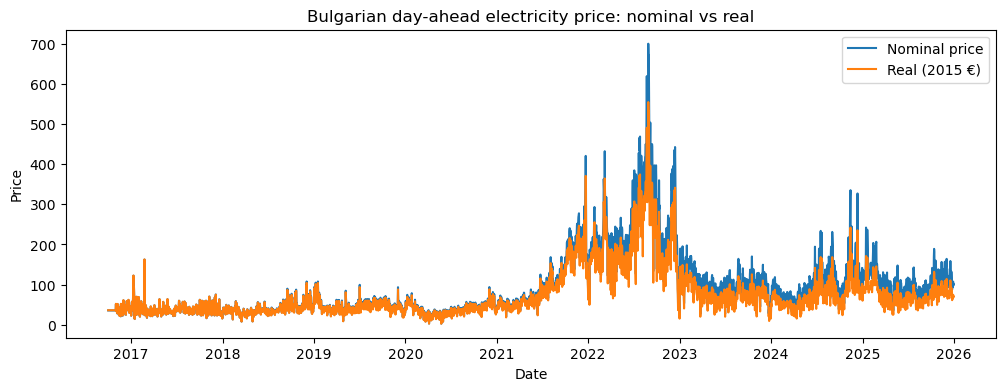

In [357]:
plt.figure(figsize=(12, 4))
plt.plot(prices["Date"], prices["Price (EUR/MWhe)"], label = "Nominal price")
plt.plot(prices["Date"], prices["Real_Price"], label = "Real (2015 €)")
plt.legend()
plt.ylabel("Price")
plt.xlabel("Date")
plt.title("Bulgarian day-ahead electricity price: nominal vs real")
plt.show()

The series track closely through 2016–2019, when HICP is near its 2015 base of 100 and the deflation factor is near 1. They diverge increasingly afterward. By 2025 the gap is roughly €25/MWh — the cumulative loss of purchasing power since 2015. The nominal series overstates the real magnitude of post-crisis prices relative to the pre-crisis baseline.

### 4.2 The weather variables

The five population-weighted national weather variables, each shown twice: as a distribution, and as a time series.

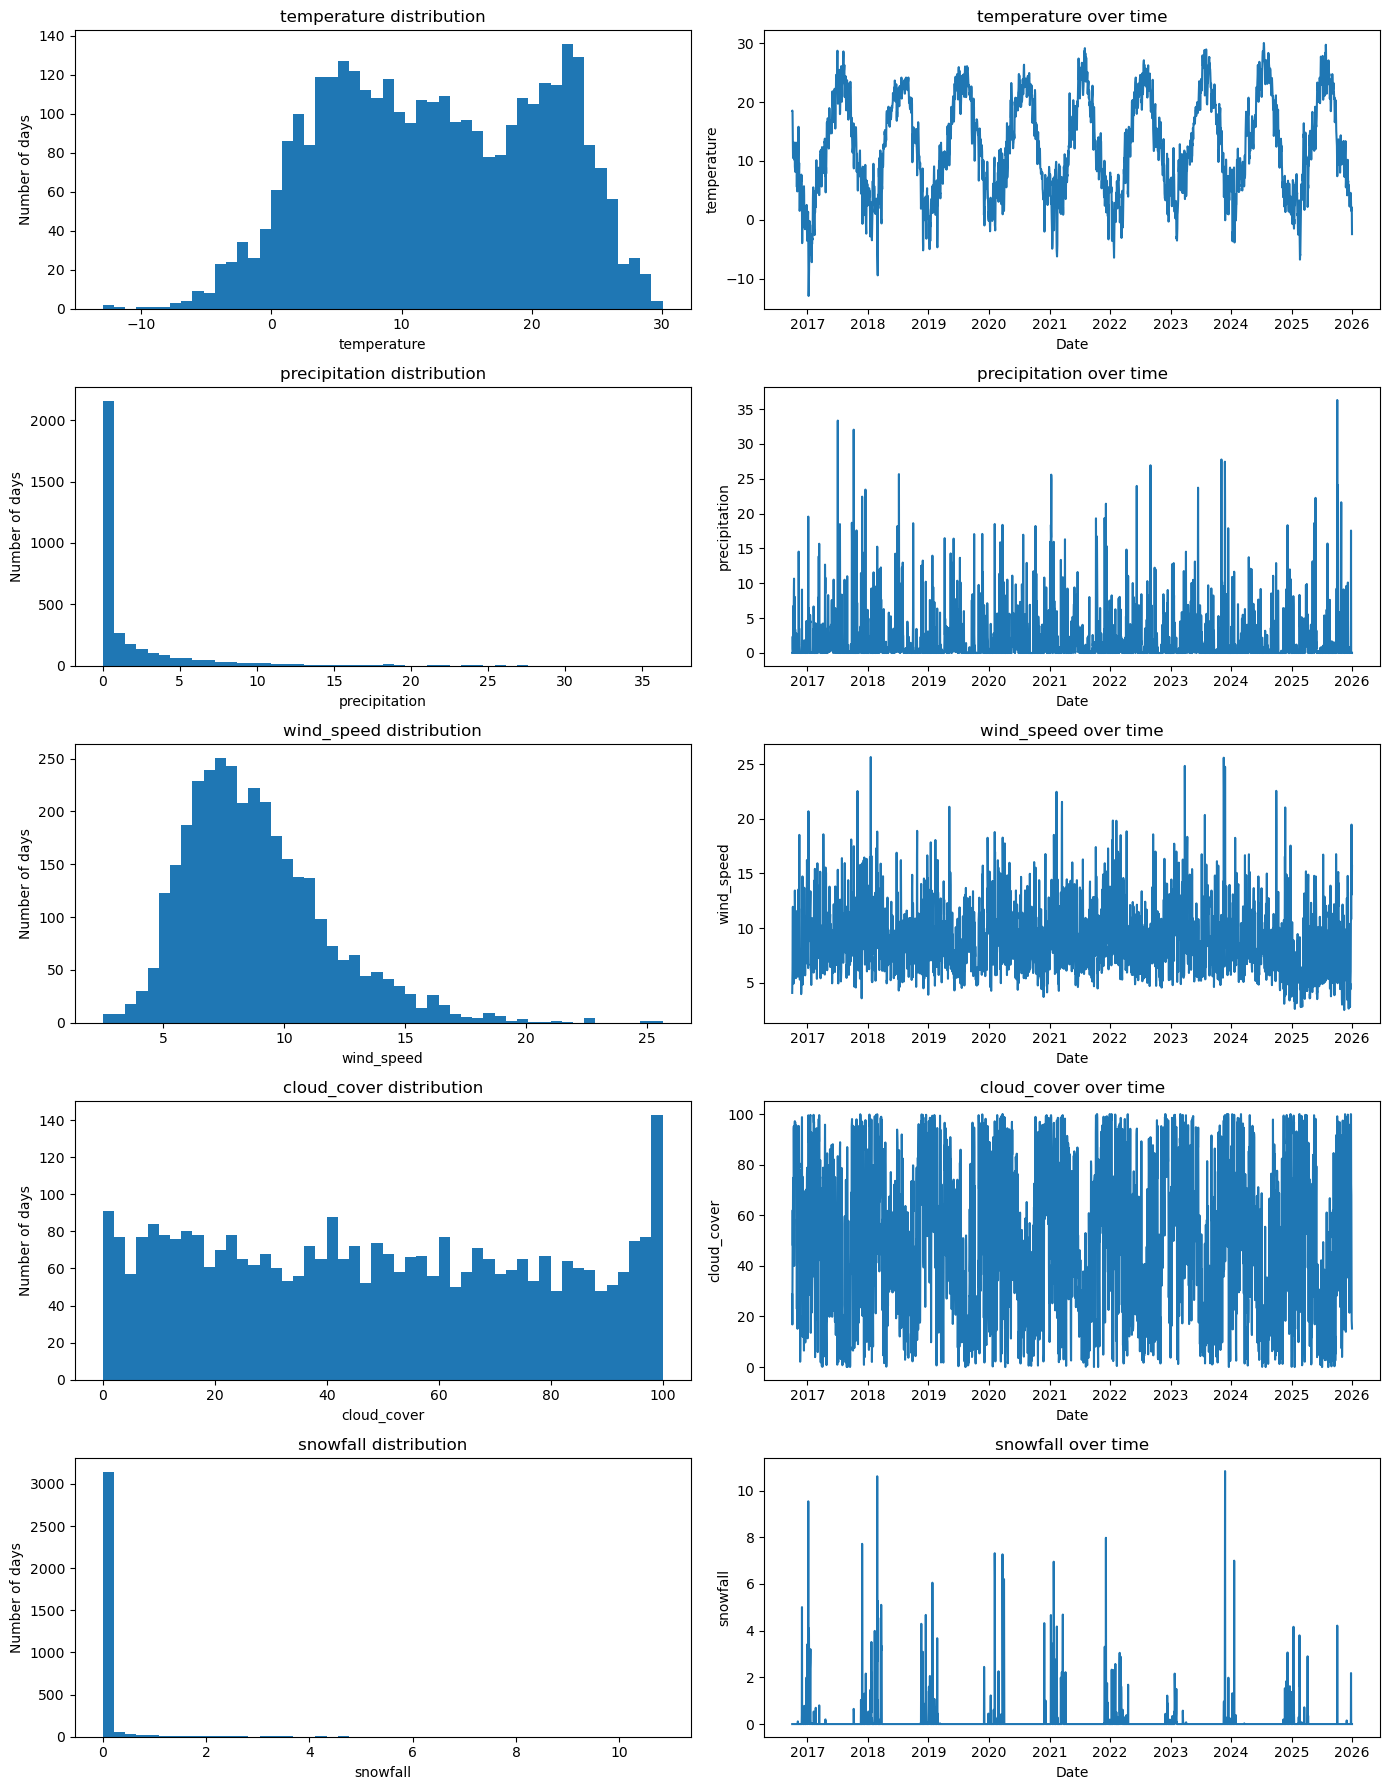

In [358]:
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
weather_vars = ["temperature", "precipitation", "wind_speed", "cloud_cover", "snowfall"]
units = {
    "temperature":   "°C",
    "precipitation": "mm/day",
    "wind_speed":    "km/h",
    "cloud_cover":   "%",
    "snowfall":      "cm/day",
}
for i, var in enumerate(weather_vars):
    # Left panel: histogram
    axes[i, 0].hist(prices[var], bins=50)
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel("Number of days")
    axes[i, 0].set_title(f"{var} distribution")
    
    # Right panel: time series
    axes[i, 1].plot(prices["Date"], prices[var])
    axes[i, 1].set_xlabel("Date")
    axes[i, 1].set_ylabel(var)
    axes[i, 1].set_title(f"{var} over time")

plt.tight_layout()
plt.show()

Temperature shows a clean annual cycle, distribution centred around +10 °C. Precipitation, snowfall, and wind speed are zero-inflated and right-skewed — typical of variables bounded below at zero. Cloud cover is more uniformly spread across 0–100%.

The time series views show no obvious trend or structural break in any weather variable. The *distribution* of weather is the same in 2017 as in 2024. This matters for the third research question: any change in the weather–price relationship across the crisis cannot be attributed to a change in the weather itself.

### 4.3 Real price stratified by season and market period

Boxplots of real price under the two stratifications used in Section 8 — by season and by market period.

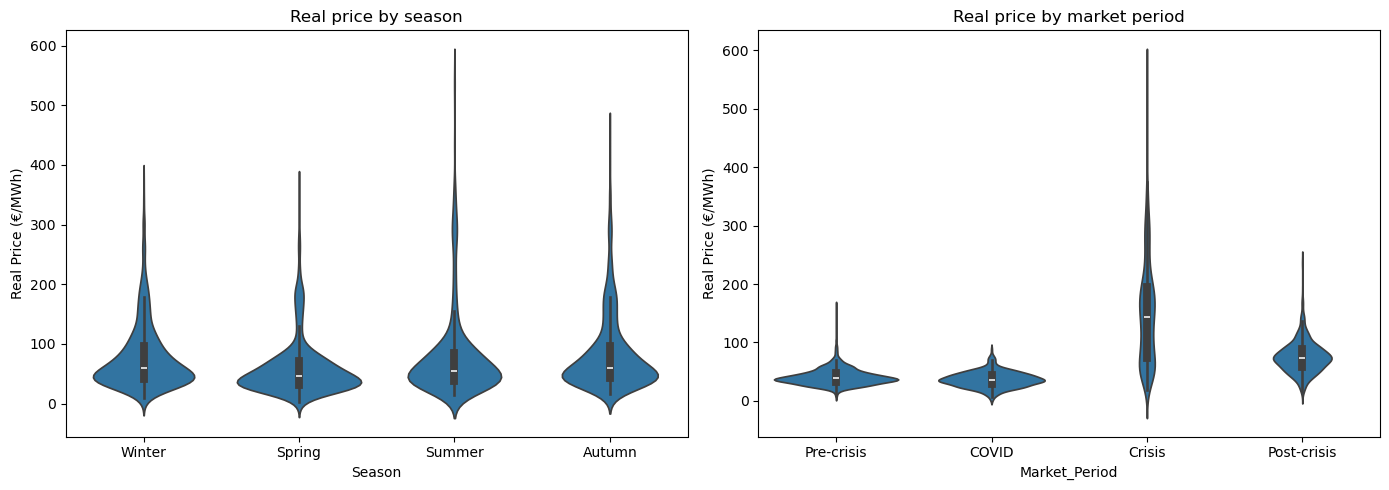

In [359]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=prices, x="Season",        y="Real_Price", ax=ax1, order=season_order)
sns.violinplot(data=prices, x="Market_Period", y="Real_Price", ax=ax2, order=period_order)

ax1.set_title("Real price by season")
ax2.set_title("Real price by market period")
ax1.set_ylabel("Real Price (€/MWh)")
ax2.set_ylabel("Real Price (€/MWh)")

plt.tight_layout()
plt.show()

**By season**, the four seasons differ less in *median* than the level might suggest — winter, summer, and autumn cluster around €55–60, with spring slightly lower at ~€45. The more striking pattern is in the *upper tails*: summer extends furthest (peaks above €500), reflecting crisis-period days within the season, while spring's upper tail is the most contained. Seasonal price variation in Bulgaria is real but modest in median terms; the dramatic excursions are not seasonal but regime-driven.

**By market period**, the four periods differ in shape, not just in level. Pre-crisis (2016 Q4 – 2019) is tight and stable around €40 — the genuine pre-disruption baseline. The COVID year (2020) is even narrower and slightly *lower* than pre-crisis, reflecting the demand suppression of pandemic restrictions. The crisis period (2021–2022) is dramatically wider, with a median several times higher than pre-crisis and a long tail extending past €500. Post-crisis (2023–2025) sits at ~€80 — narrower and more stable than the crisis period, but clearly above the pre-crisis baseline; the system has settled into a higher-priced regime that has not reverted to pre-2020 levels.

The four-period split treats COVID and the energy crisis as distinct phenomena rather than collapsing them into one "abnormal" category. They were structurally different events — one a demand shock, the other a supply shock — and folding them together would obscure the contrast that matters.

Pooling all four periods together — as Section 6 will — produces an "average relationship" that does not match the actual relationship in any individual period. This is what Section 8.2 will address.

### 4.4 Day-of-week effect on price

Wholesale electricity demand is driven heavily by industrial consumption, which drops on weekends. We expect to see a weekday-versus-weekend gap in the price series. This subsection measures the gap and checks whether it persisted through the crisis.

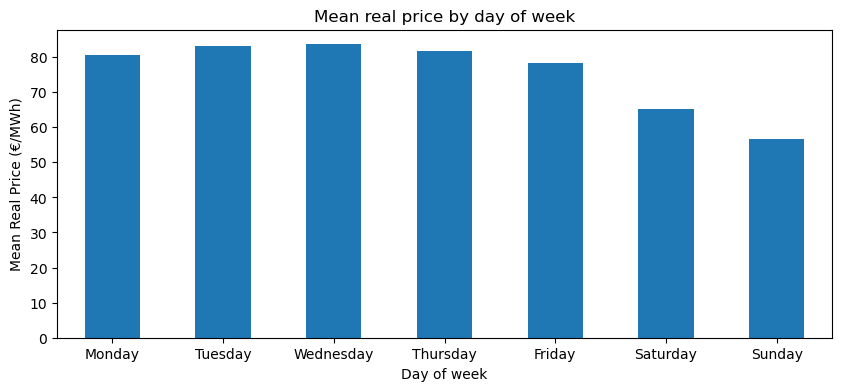

In [360]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

mean_by_day = prices.groupby(prices["Date"].dt.day_name())["Real_Price"].mean()
mean_by_day = mean_by_day.reindex(day_order)
plt.figure(figsize=(10, 4))
mean_by_day.plot(kind="bar")
plt.ylabel("Mean Real Price (€/MWh)")
plt.xlabel("Day of week")
plt.title("Mean real price by day of week")
plt.xticks(rotation=0)
plt.show()

The expected weekday-versus-weekend gap is clearly visible. Mid-week peaks at Wednesday (€84/MWh), with Tuesday and Thursday following closely. Friday already softens (€78), Saturday drops to €65, and Sunday bottoms at €57 about 32% below the Wednesday peak.

Two features are worth flagging beyond the basic effect. First, the five weekdays are tightly clustered within a €5 band, which suggests Bulgarian industrial demand is uniform across the working week. Second, the weekend itself is not symmetric: Sunday is meaningfully cheaper than Saturday (€8 lower), consistent with Sunday being the lowest-activity day in Bulgarian commercial life.

This is the wholesale-market signature of the working week industrial demand on weekdays pulls prices up; reduced demand on weekends drops them. The size of the gap (32% Wednesday-to-Sunday) is at the upper end of typical European wholesale markets, which usually show 15–25% weekend discounts.

The methodological consequence: the weather-price correlations measured in Section 6 will average across all days of the week. The day of week structure is large enough that this matters for interpretation a 32% weekend gap is a substantial source of price variation that has nothing to do with weather. However, weather variables themselves do not systematically differ by day of week (weather doesn't care what day it is), so the day of week effect should average out evenly across the analysis without biasing the correlations directionally.

### 4.5 Year-over-year drift in the pre-crisis baseline

Section 4.3 treated 2016 Q4 through 2019 as a stable pre-crisis baseline period. But three calendar years are enough for genuine drift, even without a crisis — fuel costs change, EU carbon prices evolve, the generation mix shifts. This subsection checks whether the baseline was actually stable, year by year.

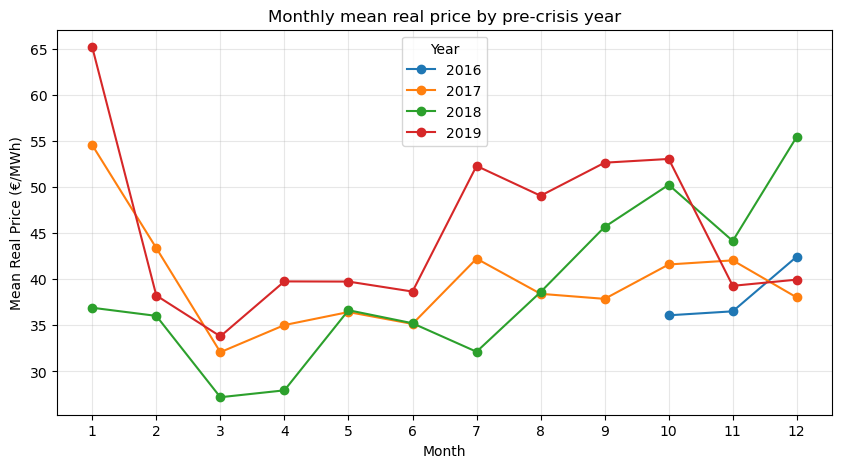

In [361]:
pre_crisis = prices[prices["Date"].dt.year < 2020]

monthly_by_year = pre_crisis.groupby(
    [pre_crisis["Date"].dt.year, pre_crisis["Date"].dt.month]
)["Real_Price"].mean()
monthly_by_year = monthly_by_year.unstack(level=0)
plt.figure(figsize=(10, 5))
monthly_by_year.plot(ax=plt.gca(), marker='o')
plt.xlabel("Month")
plt.ylabel("Mean Real Price (€/MWh)")
plt.title("Monthly mean real price by pre-crisis year")
plt.legend(title="Year")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()

The pre-crisis years are not as homogeneous as the "stable baseline" framing suggests. Three findings stand out.

First, the year-over-year differences are larger than expected: 2018 was the cheapest year (averaging around €35–40 across most months), 2017 sat roughly €5 above 2018, and 2019 ran €10–15 above both — particularly from summer onward.

Second, the differences are not driven by extreme months alone. They show up in the overall level of the seasonal cycle: 2019's price floor in spring (around €34) is higher than 2018's price ceiling in summer (around €32). The years differ in level, not just in volatility.

Third, 2019 is closer to a transitional year than a baseline year. The price elevation visible from mid-2019 onward is consistent with the rising European gas prices that would later contribute to the 2021–2022 crisis. The "pre-crisis" label is technically correct (the major spike was still two years away) but understates how much was already shifting.

Methodological consequence: when Section 8.2 compares the crisis period to "pre-crisis baseline," part of the contrast — perhaps €5–10/MWh — reflects pre-existing drift rather than crisis-induced disruption. The bulk of the contrast is genuine (the crisis pushed prices to several times the pre-crisis average), but the "baseline" itself was less stable than a single label suggests. This is acknowledged here and revisited in Section 10's limitations.

### 4.6 Price volatility across market periods

Section 4.3 showed that the periods differ in level and in the width of their distributions. But absolute width depends partly on level: a market with a higher mean naturally has higher absolute volatility. To compare volatility across periods fairly, this subsection reports the **coefficient of variation (CV)** — the sample standard deviation expressed as a fraction of the sample mean.

$$\text{CV} = \frac{s}{\bar{x}}$$

Where $s$ is the sample standard deviation of real price within the period and $\bar{x}$ is the sample mean. The CV is unitless and scale-invariant: a period with a CV of 0.5 has standard deviation equal to half its mean, regardless of whether prices are around €40 or around €150. This separates *level* from *relative volatility*, letting us compare periods of very different price ranges fairly.

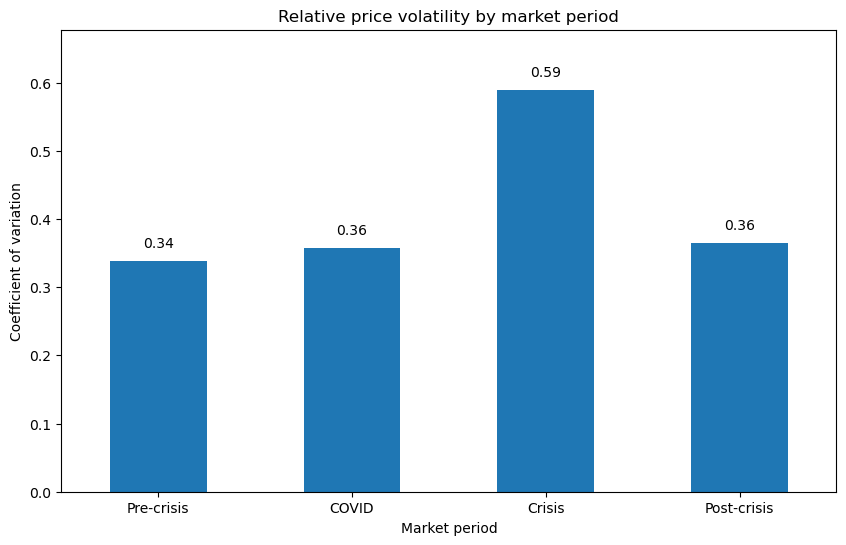

In [362]:
period_stats = prices.groupby("Market_Period", observed=True)["Real_Price"].agg(
    mean="mean",
    std="std",
    count="count"
)
period_stats["cv"] = period_stats["std"] / period_stats["mean"]
fig, ax = plt.subplots(figsize=(10, 6))
period_stats["cv"].plot(kind="bar", ax=ax)
ax.set_ylabel("Coefficient of variation")
ax.set_xlabel("Market period")
ax.set_title("Relative price volatility by market period")
ax.tick_params(axis='x', rotation=0)
ax.set_ylim(0, period_stats["cv"].max() * 1.15)
for i, v in enumerate(period_stats["cv"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

The crisis period stands alone in proportional volatility. Its coefficient of variation (0.59) is approximately 1.7× the pre-crisis baseline (0.34), meaning the wide distributions seen in Section 4.3 are not just a level effect — the crisis was genuinely more chaotic, with day-to-day swings larger as a fraction of the typical price than in any other period.

Two findings beyond the headline are worth flagging:

The COVID period (CV 0.36) was not unusually low-volatility, despite suppressed demand. The expectation — that pandemic restrictions would compress prices into a narrow range — is not what the data shows. COVID's proportional volatility is essentially the same as pre-crisis (0.36 vs 0.34); the year was lower in level but typical in spread.

Post-crisis (CV 0.36) has returned to pre-crisis volatility levels. Even with prices still roughly double the pre-crisis mean (~€78 vs ~€40), the day-to-day price swings have settled to the same proportional range as 2017–2019. This suggests the structural disruption of 2021–2022 was specific to that period, not a permanent shift in market behaviour.

Methodological consequence: when Section 6 computes correlations between weather and price across the full dataset, the crisis period contributes disproportionately to the variance — both in raw price and in proportional terms. Section 8.2's stratified analysis is therefore not just methodologically correct but practically necessary; pooling the crisis with the other three periods would let its high-CV days dominate the relationship.

### 4.7 Bulgarian weather days: a typology

A two-axis classification of days — temperature (cold/mild/warm) by precipitation (dry/wet) — produces six day types that characterise the Bulgarian climate over the analysis window. Temperature thresholds use terciles of the dataset (cold = bottom third, warm = top third, mild = middle third). Precipitation is binary: a day is "wet" if any precipitation fell, "dry" otherwise.

In [370]:
temp_terciles = prices["temperature"].quantile([0.333, 0.667])
temp_low, temp_high = temp_terciles.iloc[0], temp_terciles.iloc[1]

def classify_temperature(t):
    if t < temp_low:
        return "cold"
    elif t > temp_high:
        return "warm"
    else:
        return "mild"

prices["temp_cat"] = prices["temperature"].apply(classify_temperature)
prices["precip_cat"] = prices["precipitation"].apply(lambda p: "wet" if p >= 1.0 else "dry")
prices["day_type"] = prices["temp_cat"] + "-" + prices["precip_cat"]
day_counts = prices["day_type"].value_counts()
prices

,Country,ISO3 Code,Date,Price (EUR/MWhe),year_month,TIME_PERIOD,OBS_VALUE,Real_Price,temperature,precipitation,wind_speed,cloud_cover,snowfall,Season,Market_Period,temp_cat,precip_cat,day_type
0,Bulgaria,BGR,2016-10-01,35.53,2016-10,2016-10,98.46,36.085119,18.471514,0.000000,4.070366,28.647443,0.0,Autumn,Pre-crisis,warm,dry,warm-dry
1,Bulgaria,BGR,2016-10-02,35.53,2016-10,2016-10,98.46,36.085119,18.546951,0.000000,4.932986,16.822106,0.0,Autumn,Pre-crisis,warm,dry,warm-dry
2,Bulgaria,BGR,2016-10-03,35.53,2016-10,2016-10,98.46,36.085119,18.230524,0.234315,6.187056,39.980435,0.0,Autumn,Pre-crisis,warm,dry,warm-dry
3,Bulgaria,BGR,2016-10-04,35.53,2016-10,2016-10,98.46,36.085119,15.528293,2.365291,8.580813,62.018893,0.0,Autumn,Pre-crisis,mild,wet,mild-wet
4,Bulgaria,BGR,2016-10-05,35.53,2016-10,2016-10,98.46,36.085119,11.472123,0.625225,11.953045,48.023527,0.0,Autumn,Pre-crisis,mild,dry,mild-dry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3374,Bulgaria,BGR,2025-12-27,97.92,2025-12,2025-12,143.83,68.079238,1.515136,0.000000,16.067292,67.792444,0.0,Winter,Post-crisis,cold,dry,cold-dry
3375,Bulgaria,BGR,2025-12-28,93.65,2025-12,2025-12,143.83,65.110505,2.160068,0.121775,19.473101,43.649332,0.0,Winter,Post-crisis,cold,dry,cold-dry
3376,Bulgaria,BGR,2025-12-29,107.41,2025-12,2025-12,143.83,74.677195,1.605713,0.000000,16.154065,18.378453,0.0,Winter,Post-crisis,cold,dry,cold-dry
3377,Bulgaria,BGR,2025-12-30,97.62,2025-12,2025-12,143.83,67.870662,1.068996,0.000000,13.083620,16.341491,0.0,Winter,Post-crisis,cold,dry,cold-dry


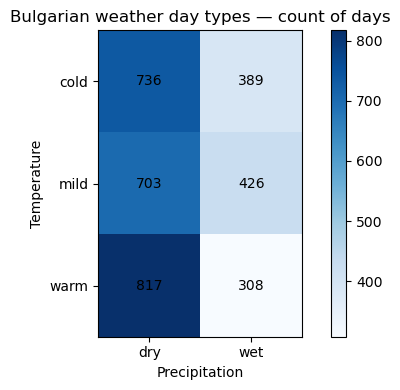

In [371]:

day_type_matrix = pd.crosstab(prices["temp_cat"], prices["precip_cat"])
day_type_matrix = day_type_matrix.reindex(["cold", "mild", "warm"])
day_type_matrix = day_type_matrix[["dry", "wet"]]


ffig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(day_type_matrix, cmap="Blues")

ax.set_xticks(range(len(day_type_matrix.columns)))
ax.set_yticks(range(len(day_type_matrix.index)))
ax.set_xticklabels(day_type_matrix.columns)
ax.set_yticklabels(day_type_matrix.index)
ax.set_xlabel("Precipitation")
ax.set_ylabel("Temperature")
ax.set_title("Bulgarian weather day types — count of days")
for i in range(len(day_type_matrix.index)):
    for j in range(len(day_type_matrix.columns)):
        ax.text(j, i, day_type_matrix.iloc[i, j], ha='center', va='center')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

The day-type distribution reveals two features of Bulgarian climate. First, dry days dominate the analysis window — 2,256 of 3,379 days (67%) had less than 1 mm of precipitation, against 1,123 wet days (33%). Bulgaria's continental climate produces more dry days than wet ones across all temperature ranges.

Second, the wet/dry ratio shifts with temperature. Warm days are the driest category overall — only 27% of warm days are wet, compared to 35% of cold days and 38% of mild days. Summer in Bulgaria is meaningfully drier than the other seasons, consistent with the Mediterranean-influenced summer dry pattern.

The largest single category is warm-dry (817 days, 24% of the window) — typical Bulgarian summer days. The smallest is warm-wet (308 days, 9%), reflecting the relative rarity of summer storms. Cold-wet days (389) are also less common than mild-wet days (426), suggesting the precipitation maximum sits in transitional seasons rather than winter.

This typology is descriptive, not analytical: Section 6 will measure correlations on the underlying continuous variables, not on categorical day types. But the typology grounds what the correlations mean — a temperature–price relationship reflects the contrast between, for example, a cold-wet winter day and a warm-dry summer day, not just a smooth response to one variable in isolation.

### 4.8 Frequency of extreme weather days

This subsection looks at how often Bulgaria has experienced extreme weather across the analysis window. "Extreme" is defined here using absolute thresholds drawn from meteorological convention, not from percentiles of the dataset itself: this lets us ask whether extremes have become more or less common over time. A percentile-based definition would have made the question meaningless — by construction, a fixed percentile of any dataset always contains the same number of days.

The thresholds:
- **Heatwave day** — daily mean temperature above 30°C
- **Cold-snap day** — daily mean temperature below -10°C
- **Heavy-rain day** — precipitation above 20 mm/day (population-weighted national)
- **Storm day** — wind speed above 30 km/h (population-weighted national)
- **Heavy-snow day** — snowfall above 3 cm/day (population-weighted national)

These thresholds use the population-weighted national index, so they correspond to events affecting most of Bulgaria's population centres simultaneously, not isolated local conditions.

The 2016 partial year (October–December only) is excluded so that all years shown are full calendar years.

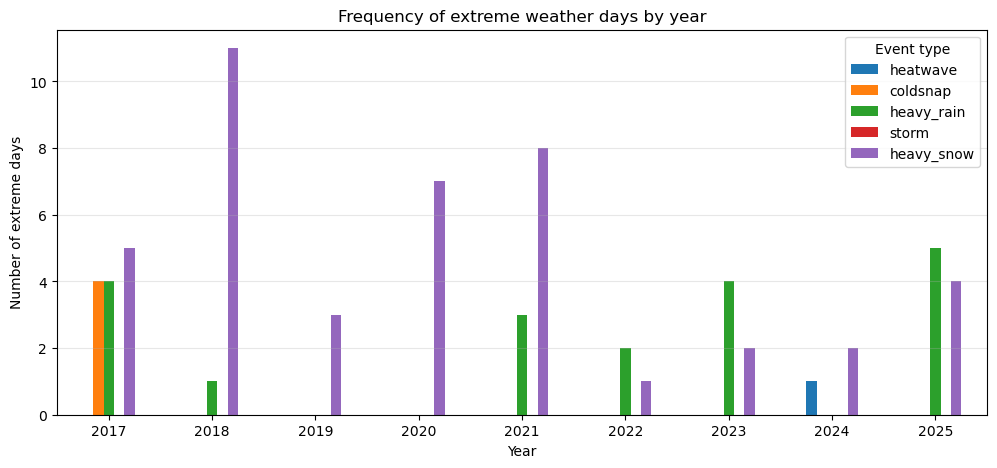

In [374]:
HEATWAVE_TEMP   = 30   
COLDSNAP_TEMP   = -10 
HEAVY_RAIN      = 20   
STORM_WIND      = 30   
HEAVY_SNOW      = 3    

full_years = prices[prices["Date"].dt.year >= 2017]
yearly_extremes = full_years.groupby(full_years["Date"].dt.year).agg(
    heatwave   = ("temperature",   lambda x: (x > HEATWAVE_TEMP).sum()),
    coldsnap   = ("temperature",   lambda x: (x < COLDSNAP_TEMP).sum()),
    heavy_rain = ("precipitation", lambda x: (x > HEAVY_RAIN).sum()),
    storm      = ("wind_speed",    lambda x: (x > STORM_WIND).sum()),
    heavy_snow = ("snowfall",      lambda x: (x > HEAVY_SNOW).sum()),
)
yearly_extremes.plot(kind="bar", figsize=(12, 5))
plt.ylabel("Number of extreme days")
plt.xlabel("Year")
plt.title("Frequency of extreme weather days by year")
plt.legend(title="Event type")
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

Most "extreme" weather days, as defined by absolute meteorological thresholds, register as heavy-snow events in this dataset. Heatwaves, cold snaps, and storms are largely absent from the population-weighted national index — only one heatwave day in 9 years, four coldsnap days, and zero storm days.

This is the expected behaviour of a population-weighted aggregate, and is well-documented in the energy-economics literature. Population-weighted heating and cooling degree-days are the standard methodology used by the U.S. Energy Information Administration for national energy forecasting (EIA), and were recently applied to Southeast Europe (including Bulgaria) by Kennard et al. (2022) and others. The aggregate dampens local extremes by construction: for the weighted-mean temperature to reach 30°C, all five major cities must approach summer peak conditions simultaneously, which is rare even during heatwaves that affect the country.

Heavy snow and heavy rain events do show up in the aggregate (30+ snow events, ~20 rain events) because precipitation is a positive sum-quantity that registers when several cities are simultaneously affected. The 2018, 2020, and 2021 snow clusters represent real winter storms that moved across Bulgaria.

Methodological consequence: the temperature correlations measured in Section 6 reflect the dampened-aggregate temperature, not single-city extremes. The correlation magnitudes are conservative estimates of the underlying weather–price relationship — the true single-city correlation would likely be stronger. This trade-off is standard in the literature and is the appropriate choice for a study of national wholesale prices.

## 5. Distribution Analysis

Section 6 will measure correlations between weather and real price. The choice of correlation method depends on whether the price distribution is roughly normal — Pearson assumes it; Spearman does not. This section runs the formal test.

### 5.1 Normality test

The Shapiro-Wilk test asks: how close is the data, when sorted, match the values you would expect from a normal distribution of the same size?

It works by sorting the observations and computing two quantities. The first is the squared sum of the sorted observations weighted by coefficients drawn from the expected order statistics of a standard normal distribution — these coefficients capture what an "ideal normal sample" of size $n$ would look like when sorted. The second is the sample variance of the data. The test statistic is the ratio of these two quantities:

$$W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}{\sum_{i=1}^{n} (x_i - \bar{x})^2}$$

where $x_{(i)}$ is the $i$-th sorted observation, $a_i$ are the normality coefficients, and $\bar{x}$ is the sample mean. $W$ is bounded between 0 and 1: values close to 1 mean the sorted data closely match the shape of a normal distribution; lower values mean it doesn't. The corresponding p-value tests the null hypothesis that the data was drawn from a normal population — a p-value below 0.05 rejects normality.

A practical caveat: the test has very high statistical power on samples this large (n = 3,379). Even small departures from normality produce strong rejections. The W statistic itself, alongside the skewness and kurtosis values that follow, gives a better sense of *how* non-normal the distribution is.

In [375]:
W, p = shapiro(prices['Real_Price'])
print(f"W = {W:.4f}, p = {p:.2e}")

W = 0.7311, p = 4.26e-59


W = 0.731, p < 0.001. The null hypothesis of normality is decisively rejected. The W statistic of 0.731 — well below 1 — confirms the distribution departs substantially from normal, not just marginally. The p-value of 4.26×10⁻⁵⁹ is effectively zero: the probability of observing data this non-normal by chance, if the true distribution were normal, is negligible.

### 5.2 Skewness and kurtosis


In [376]:
skew = prices['Real_Price'].skew()
kurt = prices['Real_Price'].kurtosis()
print(f"Skewness:        {skew:.3f}")
print(f"Excess kurtosis: {kurt:.3f}")

Skewness:        2.529
Excess kurtosis: 8.340


Skewness = 2.529: the distribution has a pronounced right tail. The mean (€75.62) sits well above the median (€54.76) because crisis-period extremes pull it upward — the textbook signature of positive skew. A value above 1 is generally considered substantially skewed; 2.529 is well into that territory.

Excess kurtosis = 8.340: the tails are far heavier than a normal distribution would produce. A normal distribution has excess kurtosis of 0; a value of 8.340 means extreme observations occur much more frequently than normality would predict. Again, the crisis-period days are the direct cause — they sit far into the upper tail and contribute disproportionately to the kurtosis statistic.

Both values confirm what Section 4 showed visually. The formal statistics now put numbers on it.

### 5.3 Conclusion

Three statistics converge on the same answer: W = 0.731, skewness = 2.529, excess kurtosis = 8.340. The real price distribution is non-normal, right-skewed, and heavy-tailed. Pearson correlation — which assumes normality and is sensitive to outliers — would give disproportionate weight to the crisis-period extremes and produce a coefficient that does not reflect the typical weather–price relationship.

## 6. Correlation Analysis

This section measures the strength and direction of the relationship between each weather variable and real price. Pearson correlation is the default measure of association, but it assumes both variables are roughly normally distributed and that their relationship is linear. Section 5 showed that real price is non-normal (W = 0.731, skewness = 2.529, excess kurtosis = 8.340), so the default assumption fails. Spearman rank correlation is used instead — it makes no distributional assumptions and is robust to the outliers that the crisis period introduces.

Each subsection covers one weather variable: the correlation coefficient $\rho$, its 95% confidence interval, and its p-value. Section 6.6 brings all five results together and ranks them by effect size.

Effect size and statistical significance are reported separately and interpreted together. With $n = 3{,}379$, even small correlations reach statistical significance — a correlation of $\rho = 0.04$ would produce $p < 0.05$ at this sample size. Statistical significance alone is therefore not informative; the magnitude of $\rho$ and the width of the confidence interval matter.

### 6.1 Method

#### Spearman rank correlation

Spearman rank correlation replaces each observation with its rank — the highest value gets rank $n$, the lowest gets rank 1 — then computes Pearson correlation on the ranks. This removes the influence of the actual magnitudes and makes the result robust to outliers and non-linearity.

The coefficient is:

$$\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}$$

where $d_i$ is the difference between observation $i$'s rank in the weather variable and its rank in real price, and $n$ is the sample size. $\rho$ ranges from $-1$ (perfect inverse relationship) to $+1$ (perfect positive relationship).

#### Significance testing

For each variable we test:

$$H_0: \rho = 0 \qquad H_1: \rho \neq 0$$

The test statistic is:

$$t = \rho \sqrt{\frac{n - 2}{1 - \rho^2}}$$

Under $H_0$ this follows a t-distribution with $n - 2$ degrees of freedom. The p-value is returned directly by `scipy.stats.spearmanr`.

#### Confidence intervals: Fisher z-transformation

Because $\rho$ is bounded between $-1$ and $+1$, a direct normal approximation on the raw coefficient is unreliable near the boundaries. The Fisher z-transformation maps $\rho$ to an approximately normal scale:

$$z = \text{arctanh}(\rho) = \frac{1}{2} \ln\left(\frac{1 + \rho}{1 - \rho}\right)$$

The standard error of $z$ is $\frac{1}{\sqrt{n - 3}}$, giving a 95% confidence interval in z-space:

$$z \pm \frac{1.96}{\sqrt{n - 3}}$$

The bounds are transformed back using $\rho = \tanh(z)$, producing a CI that is guaranteed to stay within $(-1, 1)$.

### 6.2 Spearman correlations: all weather variables

The Spearman correlation between each weather variable and real price, computed across the full October 2016 – December 2025 window.

In [377]:
from scipy.stats import spearmanr
import numpy as np

weather_vars = ["temperature", "precipitation", "wind_speed", "cloud_cover", "snowfall"]
n = len(prices)
results = []

for var in weather_vars:
    rho, p = spearmanr(prices[var], prices["Real_Price"])
    z = np.arctanh(rho)
    se = 1 / np.sqrt(n - 3)
    ci_low  = np.tanh(z - 1.96 * se)
    ci_high = np.tanh(z + 1.96 * se)
    results.append({
        "Variable":   var,
        "ρ":          round(rho, 4),
        "CI low":     round(ci_low, 4),
        "CI high":    round(ci_high, 4),
        "p-value":    f"{p:.2e}",
    })

results_df = pd.DataFrame(results).set_index("Variable")
results_df.sort_values("ρ", key=abs, ascending=False)

,ρ,CI low,CI high,p-value
Variable,,,,
wind_speed,-0.0854,-0.1188,-0.0518,6.67e-07
snowfall,0.0494,0.0157,0.0829,4.11e-03
precipitation,-0.0388,-0.0725,-0.0051,2.40e-02
temperature,-0.0177,-0.0514,0.0161,3.04e-01
cloud_cover,0.0111,-0.0227,0.0448,5.20e-01


The results present a clear hierarchy by effect size, with all five coefficients small in absolute terms.

**Wind speed** (ρ = −0.085, 95% CI [−0.119, −0.052], p < 0.001) is the strongest relationship in the table. The direction is negative — windier days have lower prices — consistent with wind generation displacing more expensive thermal generation. The relationship is highly significant and the CI is comfortably away from zero, making this the most reliable finding in the simple correlation analysis.

**Snowfall** (ρ = 0.049, 95% CI [0.016, 0.083], p = 0.004) is positive and significant. Snow days tend to have slightly higher prices, consistent with cold weather increasing heating demand. The coefficient is small but the CI does not include zero.

**Precipitation** (ρ = −0.039, 95% CI [−0.073, −0.005], p = 0.024) is negative and significant — wetter days have slightly lower prices. The direction is counterintuitive at first glance; one possible explanation is that precipitation increases hydroelectric inflow, which raises generation capacity and puts downward pressure on the marginal price. The coefficient is small and the CI barely excludes zero.

**Temperature** (ρ = −0.018, 95% CI [−0.051, 0.016], p = 0.304) is not statistically significant. The CI includes zero; H₀: ρ = 0 cannot be rejected. This is the most important result in the table — temperature is the weather variable most directly linked to electricity demand through heating and cooling, yet no significant monotonic relationship is visible across the full window. Two factors likely explain the absence. First, the 2021–2022 energy crisis introduced sustained high prices driven by gas market dynamics rather than weather; including these days dilutes the temperature signal because crisis-period prices are elevated regardless of temperature. Second, the relationship may be non-linear — both very cold and very hot days drive demand higher, while mild days have the lowest demand. Spearman measures monotonic association and cannot capture a U-shaped relationship. Section 8.2 will test the first explanation directly by re-running the correlation within each market period.

**Cloud cover** (ρ = 0.011, 95% CI [−0.023, 0.045], p = 0.520) shows no detectable relationship with price. The CI spans both positive and negative values; the result is consistent with zero.

**Effect size vs statistical significance.** With n = 3,379, even ρ = 0.039 produces p < 0.05. The three significant results — wind speed, snowfall, precipitation — are real in the sense that they are unlikely to reflect sampling noise. But none of the five coefficients approach a practically meaningful magnitude by conventional benchmarks (|ρ| > 0.3 is typically considered moderate). The simple pairwise correlations across the full window are weak. Section 7 examines whether controlling for inter-variable correlations changes this picture, and Section 8 tests whether the relationships strengthen when the crisis period is isolated.